<a href="https://colab.research.google.com/github/Garfieldslard/Crime-Analysis/blob/main/DATA_205_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the cleaned datasets

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

crime_df = pd.read_csv('/crime_filtered.csv')
arrests_df = pd.read_csv('/daily_arrests_cleaned.csv')
dispatch_df = pd.read_csv('/dispatch_filtered.csv')

crime_df.columns = crime_df.columns.str.strip().str.lower().str.replace(' ', '_')
dispatch_df.columns = dispatch_df.columns.str.strip().str.lower().str.replace(' ', '_')
dispatch_df.columns = dispatch_df.columns.str.replace('/', '_', regex=False)
arrests_df.columns = arrests_df.columns.str.strip().str.lower().str.replace(' ', '_')

/tmp/ipykernel_11966/1726997690.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_df = pd.read_csv('/crime_filtered.csv')


Convert date columns

In [19]:
crime_df['start_date_time'] = pd.to_datetime(crime_df['start_date_time'], errors='coerce')
dispatch_df['start_time'] = pd.to_datetime(dispatch_df['start_time'], errors='coerce')
arrests_df['arrest_date'] = pd.to_datetime(arrests_df['arrest_date'], errors='coerce')

Creating daily counts

In [21]:
crime_daily = crime_df.groupby(crime_df['start_date_time'].dt.date).size()

dispatch_daily = dispatch_df.groupby(dispatch_df['start_time'].dt.date).size()

arrests_daily = arrests_df.groupby(arrests_df['arrest_date'].dt.date).size()

Combine Datasets

In [22]:
eda_df = pd.DataFrame({
    'Crime': crime_daily,
    'Dispatch': dispatch_daily,
    'Arrests': arrests_daily
}).fillna(0)

eda_df.index = pd.to_datetime(eda_df.index)
eda_df = eda_df.sort_index()

eda_df.head()

,Crime,Dispatch,Arrests
2025-01-01,149.0,596,0.0
2025-01-02,133.0,493,0.0
2025-01-03,118.0,557,0.0
2025-01-04,106.0,524,0.0
2025-01-05,99.0,453,0.0


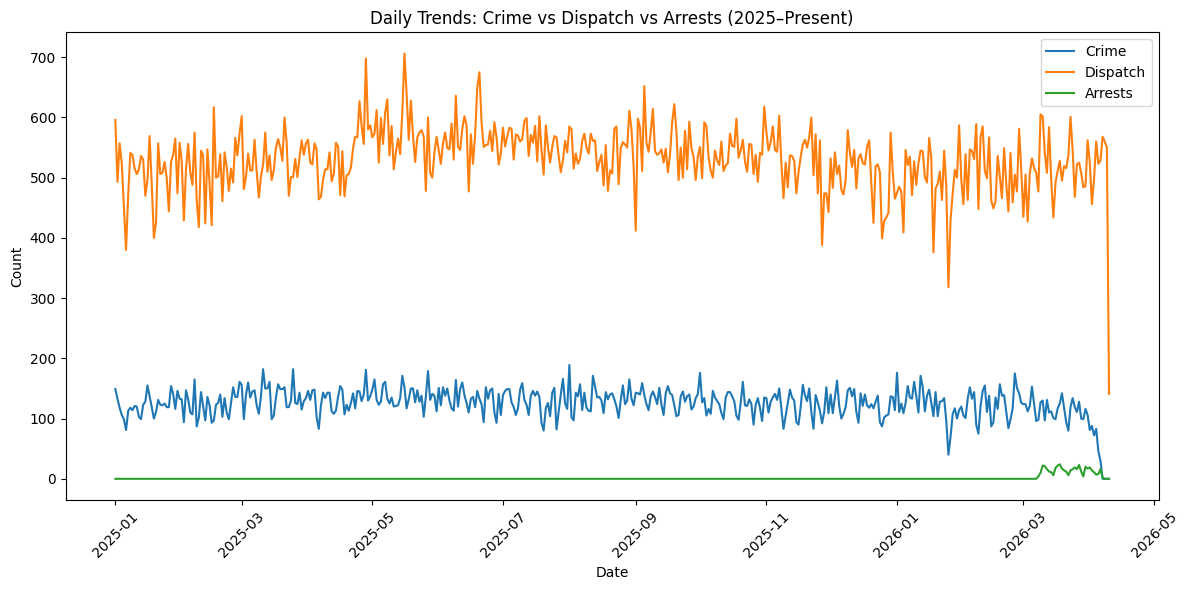

In [23]:
plt.figure(figsize=(12,6))

plt.plot(eda_df.index, eda_df['Crime'], label='Crime')
plt.plot(eda_df.index, eda_df['Dispatch'], label='Dispatch')
plt.plot(eda_df.index, eda_df['Arrests'], label='Arrests')

plt.title("Daily Trends: Crime vs Dispatch vs Arrests (2025–Present)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

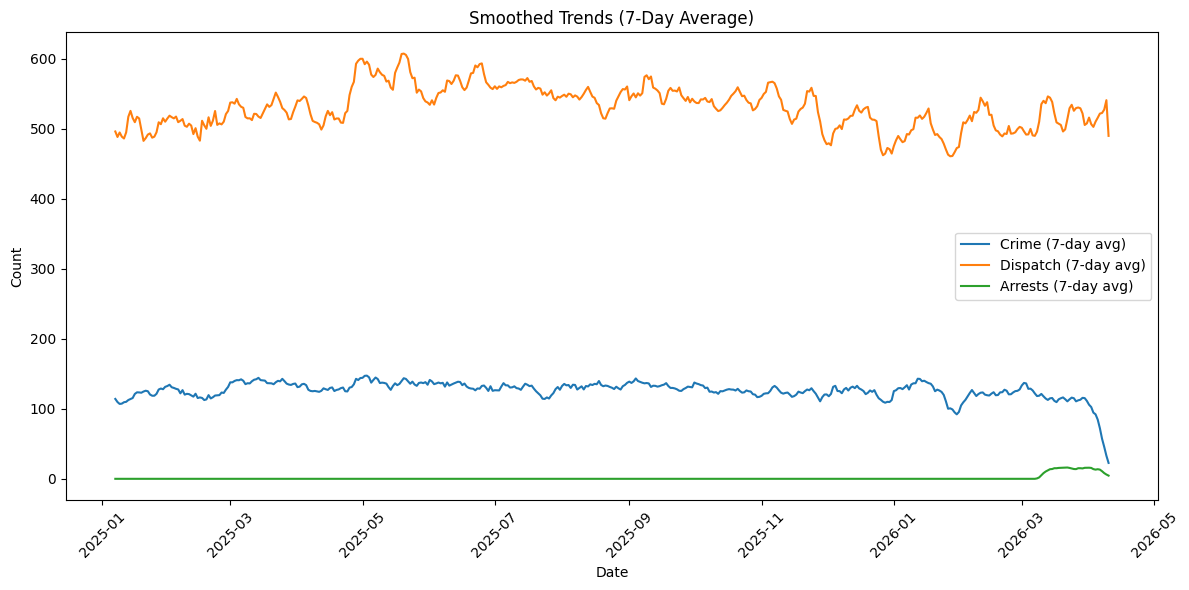

In [24]:
eda_smooth = eda_df.rolling(window=7).mean()

plt.figure(figsize=(12,6))

plt.plot(eda_smooth.index, eda_smooth['Crime'], label='Crime (7-day avg)')
plt.plot(eda_smooth.index, eda_smooth['Dispatch'], label='Dispatch (7-day avg)')
plt.plot(eda_smooth.index, eda_smooth['Arrests'], label='Arrests (7-day avg)')

plt.title("Smoothed Trends (7-Day Average)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
eda_df.corr()

,Crime,Dispatch,Arrests
Crime,1.000000,0.403778,-0.179704
Dispatch,0.403778,1.000000,-0.029450
Arrests,-0.179704,-0.029450,1.000000


Crime and dispatch have a moderate positive correlation. Crime and arrests have a weak negative correlation. Dispatch and arrests have almost no correlation.